**Load the Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Google Sheet CSV export link
sheet_url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"

# Read sheet directly into pandas
df = pd.read_csv(sheet_url)

# Preview
print(df.shape)
df.head()

(846, 25)


,name,file,transcript,text_length,age,gender,race,language,wps,readability,...,WX_WER,ZM_WER,BJ_WER,GM,YT,MS,FB,ZM,BJ,WX
0,Aaron Huey,AaronHuey_2010X,i m here today to show my photographs of the l...,2211,35.0,male,white,us,2.380,7.35,...,0.12489,0.06700,0.06335,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,here today to show my photographs of the lakot...,hello i m here today to show my photographs of...
1,Abha Dawesar,AbhaDawesar_2013G,i was in new york during hurricane sandy and t...,1988,39.0,female,asian,l2,2.753,6.98,...,0.05989,0.04680,0.04076,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,hello i was in new york during hurricane sandy...
2,Abigail Marsh,AbigailMarsh_2016T,there s a man out there somewhere who looks a ...,2044,40.0,female,white,us,2.737,6.97,...,0.11373,0.05980,0.06667,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,here s a man out going somewhere who looks a l...,hello there s a man out there somewhere who lo...
3,Abraham Verghese,AbrahamVerghese_2011G,a few months ago a forty year old woman came t...,3084,56.0,male,asian,l2,2.767,6.94,...,0.09123,0.07103,0.07071,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,few months ago a forty year old woman came to ...,hello a few months ago a forty year old woman ...
4,Achenyo Idachaba,AchenyoIdachaba_2015W,welcome to bayeku a riverine community in ikor...,943,45.0,female,black,l2,2.133,7.64,...,0.17535,0.12752,0.09139,welcome to buyiku a riverine community in ikor...,welcome to bayeku a riverine community in ikor...,welcome to becu a riverine community in ecuado...,welcome to baiku a riverine community in ikoro...,welcome to baiku riverine community in icarudu...,welcome to baku a riverine community in ikorod...,welcome to river wind community in a vivid rep...


In [4]:
# drop empty texts
df = df.dropna(subset=["transcript"])

**Handle Multilingual Texts**

In [4]:
pip install sentence-transformers


**Create Stance Labels Automatically**

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# multilingual model
model = SentenceTransformer('sentence-transformers/LaBSE')

# encode the transcripts (embeddings)
embeddings = model.encode(df["transcript"].tolist(), show_progress_bar=True)

# cluster into stance groups (try 3: support / neutral / oppose)
kmeans = KMeans(n_clusters=3, random_state=42)
df["stance_cluster"] = kmeans.fit_predict(embeddings)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

**Inspect and Rename Clusters**

In [6]:
for i in range(3):
    print(f"\nCluster {i}")
    print(df[df["stance_cluster"] == i]["transcript"].sample(2).values)



Cluster 0
['george and charlotte blonsky who were a married couple living in the bronx in new york city invented something they got a patent in one thousand nine hundred and sixty five for what they call a device to assist women in giving birth this device consists of a large round table and some machinery when the woman is ready to deliver her child she lies on her back she is strapped down to the table and the table is rotated at high speed the child comes flying out through centrifugal force if you look at their patent carefully especially if you have any engineering background or talent you may decide that you see one or two points where the design is not perfectly adequate doctor ivan schwab in california is one of the people one of the main people who helped answer the question why don t woodpeckers get headaches and it turns out the answer to that is because their brains are packaged inside their skulls in a way different from the way our brains we being human beings true have 

In [7]:
mapping = {0: "supportive", 1: "critical", 2: "neutral"}
df["stance_label"] = df["stance_cluster"].map(mapping)


In [10]:
df.to_csv("stance_dataset.csv", index=False)


In [12]:
df = pd.read_csv("stance_dataset.csv")


**Split Data for Training (80:10:10)**

In [9]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["stance_label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["stance_label"]
)


**Train the Stance Classifier**

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# train SVM on ground truth embeddings
train_embeds = model.encode(train_df["transcript"].tolist(), show_progress_bar=True)
val_embeds   = model.encode(val_df["transcript"].tolist(), show_progress_bar=True)

clf = SVC(kernel='linear', class_weight='balanced', probability=True)
clf.fit(train_embeds, train_df["stance_label"])

val_preds = clf.predict(val_embeds)
print(classification_report(val_df["stance_label"], val_preds))


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    critical       0.92      0.92      0.92        25
     neutral       0.94      0.97      0.96        34
  supportive       1.00      0.96      0.98        26

    accuracy                           0.95        85
   macro avg       0.95      0.95      0.95        85
weighted avg       0.95      0.95      0.95        85



In [11]:
# === ADD STANCE SCORES HERE ===
val_proba = clf.predict_proba(val_embeds)

val_df["stance_pred"]  = val_preds
val_df["stance_score"] = val_proba.max(axis=1)

val_df[["transcript", "stance_label", "stance_pred", "stance_score"]].head()


,transcript,stance_label,stance_pred,stance_score
392,ladies and gentlemen gather around i would lov...,neutral,neutral,0.925246
175,how many of you have used an electronic spread...,critical,critical,0.772826
597,you may never have heard of kenema sierra leon...,supportive,supportive,0.959686
804,some years ago i stumbled across a simple desi...,supportive,supportive,0.901605
626,i am going to speak about corruption but i wou...,critical,critical,0.999866


**Predict on Each ASR Output**

In [12]:
asr_cols = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

for col in asr_cols:
    asr_embeds = model.encode(df[col].astype(str).tolist(), show_progress_bar=True)
    df[f"{col}_stance_pred"] = clf.predict(asr_embeds)


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

**Measure Bias (Stance Flip vs WER)**

In [13]:
flip_results = {}
for col in asr_cols:
    flip_rate = (df[f"{col}_stance_pred"] != df["stance_label"]).mean()
    flip_results[col] = round(flip_rate * 100, 2)
    print(f"{col}: {flip_results[col]}% stance flips")


GM: 2.84% stance flips
YT: 2.72% stance flips
MS: 2.48% stance flips
FB: 2.36% stance flips
ZM: 2.96% stance flips
BJ: 2.72% stance flips
WX: 2.48% stance flips


**Correlate with WER**

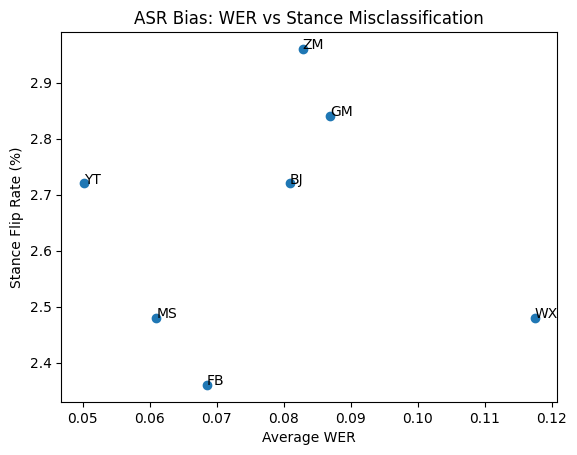

In [14]:
import matplotlib.pyplot as plt

mean_wers = [df[f"{col}_WER"].mean() for col in asr_cols]
flip_rates = [flip_results[col] for col in asr_cols]

plt.scatter(mean_wers, flip_rates)
for i, col in enumerate(asr_cols):
    plt.text(mean_wers[i], flip_rates[i], col)
plt.xlabel("Average WER")
plt.ylabel("Stance Flip Rate (%)")
plt.title("ASR Bias: WER vs Stance Misclassification")
plt.show()


**Bias Analysis**

*(a) Bias by Language*

In [15]:
!pip install langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=3eaefe1f1d1c2192a1fd5ddd583885daaa45dd4ef9e383697094ad7ab8c17762
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [16]:
from langdetect import detect
import numpy as np

# Detect dominant language for each transcript
df["lang_detected"] = df["transcript"].apply(lambda x: detect(x) if isinstance(x, str) else "unknown")

# Compute stance flip rates for each ASR per language
asr_cols = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

bias_by_lang = []

for lang in df["lang_detected"].unique():
    subset = df[df["lang_detected"] == lang]
    if len(subset) < 5:
        continue  # skip small groups for stability
    for asr in asr_cols:
        flip_rate = (subset[f"{asr}_stance_pred"] != subset["stance_label"]).mean()
        avg_wer = subset[f"{asr}_WER"].mean()
        bias_by_lang.append({
            "Language": lang,
            "ASR": asr,
            "Mean_WER": round(avg_wer, 3),
            "Stance_Flip_Rate(%)": round(flip_rate * 100, 2),
            "Samples": len(subset)
        })

lang_bias_df = pd.DataFrame(bias_by_lang)
lang_bias_df.head()


,Language,ASR,Mean_WER,Stance_Flip_Rate(%),Samples
0,en,GM,0.087,2.84,846
1,en,YT,0.050,2.72,846
2,en,MS,0.061,2.48,846
3,en,FB,0.069,2.36,846
4,en,ZM,0.083,2.96,846


In [17]:
from tabulate import tabulate
print(tabulate(lang_bias_df.head(10), headers='keys', tablefmt='psql'))


+----+------------+-------+------------+-----------------------+-----------+
|    | Language   | ASR   |   Mean_WER |   Stance_Flip_Rate(%) |   Samples |
|----+------------+-------+------------+-----------------------+-----------|
|  0 | en         | GM    |      0.087 |                  2.84 |       846 |
|  1 | en         | YT    |      0.05  |                  2.72 |       846 |
|  2 | en         | MS    |      0.061 |                  2.48 |       846 |
|  3 | en         | FB    |      0.069 |                  2.36 |       846 |
|  4 | en         | ZM    |      0.083 |                  2.96 |       846 |
|  5 | en         | BJ    |      0.081 |                  2.72 |       846 |
|  6 | en         | WX    |      0.117 |                  2.48 |       846 |
+----+------------+-------+------------+-----------------------+-----------+


*(b) Bias by Gender*

In [18]:
# ----------------------------
# 2) GENDER BIAS DATAFRAME
# ----------------------------
bias_by_gender = []

for gender in df["gender"].dropna().unique():
    subset = df[df["gender"] == gender]
    if len(subset) < 5:
        continue

    for asr in asr_cols:
        flip_rate = (subset[f"{asr}_stance_pred"] != subset["stance_label"]).mean()
        avg_wer = subset[f"{asr}_WER"].mean()
        bias_by_gender.append({
            "Gender": gender,
            "ASR": asr,
            "Mean_WER": round(avg_wer, 3),
            "Stance_Flip_Rate(%)": round(flip_rate * 100, 2),
            "Samples": len(subset)
        })

gender_bias_df = pd.DataFrame(bias_by_gender)


In [19]:
!pip install tabulate
from tabulate import tabulate
print(tabulate(gender_bias_df.head(10), headers='keys', tablefmt='psql'))


+----+----------+-------+------------+-----------------------+-----------+
|    | Gender   | ASR   |   Mean_WER |   Stance_Flip_Rate(%) |   Samples |
|----+----------+-------+------------+-----------------------+-----------|
|  0 | male     | GM    |      0.094 |                  2.92 |       548 |
|  1 | male     | YT    |      0.055 |                  2.55 |       548 |
|  2 | male     | MS    |      0.066 |                  1.82 |       548 |
|  3 | male     | FB    |      0.074 |                  1.82 |       548 |
|  4 | male     | ZM    |      0.088 |                  2.74 |       548 |
|  5 | male     | BJ    |      0.086 |                  2.01 |       548 |
|  6 | male     | WX    |      0.122 |                  2.37 |       548 |
|  7 | female   | GM    |      0.075 |                  2.68 |       298 |
|  8 | female   | YT    |      0.041 |                  3.02 |       298 |
|  9 | female   | MS    |      0.052 |                  3.69 |       298 |
+----+----------+-------+

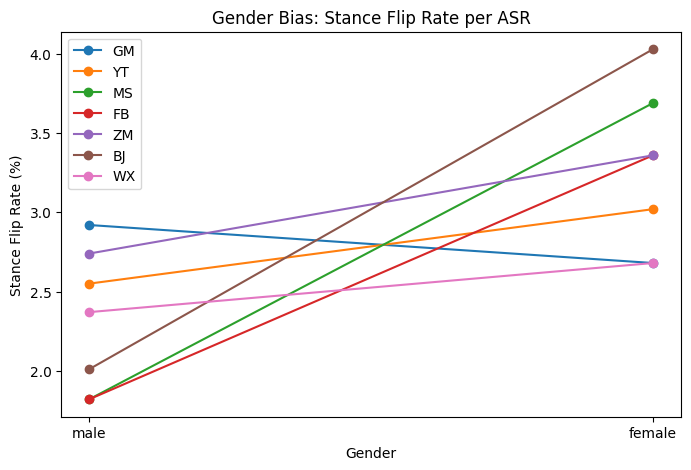

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for asr in asr_cols:
    subset = gender_bias_df[gender_bias_df["ASR"] == asr]
    plt.plot(subset["Gender"], subset["Stance_Flip_Rate(%)"], marker='o', label=asr)

plt.title("Gender Bias: Stance Flip Rate per ASR")
plt.xlabel("Gender")
plt.ylabel("Stance Flip Rate (%)")
plt.legend()
plt.show()


*(c) Bias by Race / Ethnicity*

In [21]:
# ----------------------------
# CREATE RACE BIAS DATAFRAME
# ----------------------------
asr_cols = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

bias_by_race = []

for race in df["race"].dropna().unique():
    subset = df[df["race"] == race]
    if len(subset) < 5:
        continue  # avoid small unstable groups

    for asr in asr_cols:
        flip_rate = (subset[f"{asr}_stance_pred"] != subset["stance_label"]).mean()
        avg_wer = subset[f"{asr}_WER"].mean()

        bias_by_race.append({
            "Race": race,
            "ASR": asr,
            "Mean_WER": round(avg_wer, 3),
            "Stance_Flip_Rate(%)": round(flip_rate * 100, 2),
            "Samples": len(subset)
        })

race_bias_df = pd.DataFrame(bias_by_race)


In [22]:
!pip install tabulate
from tabulate import tabulate

print(tabulate(race_bias_df.head(10), headers='keys', tablefmt='psql'))


+----+--------+-------+------------+-----------------------+-----------+
|    | Race   | ASR   |   Mean_WER |   Stance_Flip_Rate(%) |   Samples |
|----+--------+-------+------------+-----------------------+-----------|
|  0 | white  | GM    |      0.086 |                  2.92 |       651 |
|  1 | white  | YT    |      0.049 |                  2.92 |       651 |
|  2 | white  | MS    |      0.06  |                  2.46 |       651 |
|  3 | white  | FB    |      0.067 |                  2.46 |       651 |
|  4 | white  | ZM    |      0.08  |                  2.92 |       651 |
|  5 | white  | BJ    |      0.078 |                  2.76 |       651 |
|  6 | white  | WX    |      0.113 |                  2.76 |       651 |
|  7 | asian  | GM    |      0.086 |                  4.81 |       104 |
|  8 | asian  | YT    |      0.052 |                  3.85 |       104 |
|  9 | asian  | MS    |      0.064 |                  4.81 |       104 |
+----+--------+-------+------------+---------------

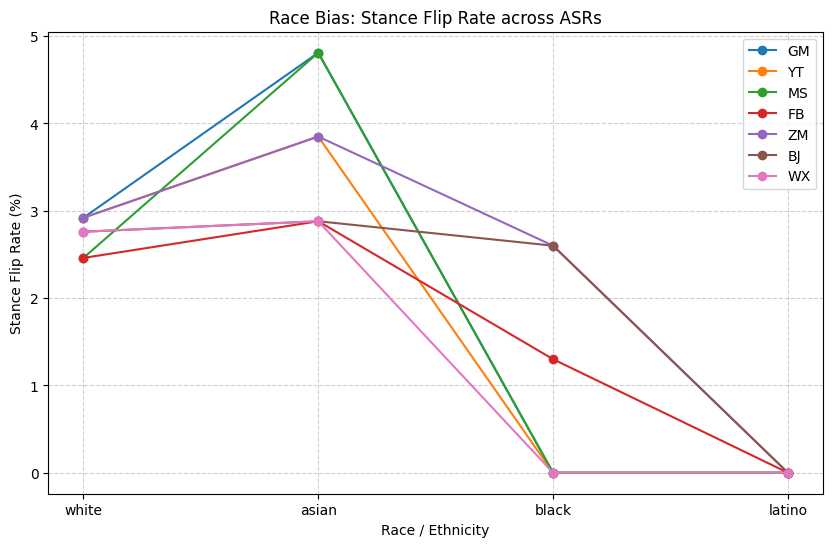

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for asr in asr_cols:
    subset = race_bias_df[race_bias_df["ASR"] == asr]
    plt.plot(subset["Race"], subset["Stance_Flip_Rate(%)"], marker='o', label=asr)

plt.title("Race Bias: Stance Flip Rate across ASRs")
plt.xlabel("Race / Ethnicity")
plt.ylabel("Stance Flip Rate (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


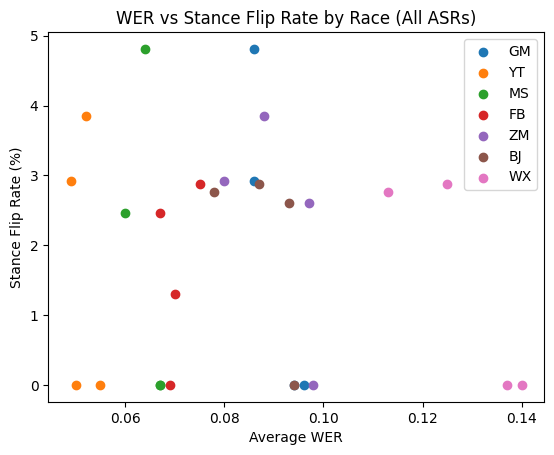

In [24]:
import matplotlib.pyplot as plt

plt.figure()
for asr in asr_cols:
    subset = race_bias_df[race_bias_df["ASR"] == asr]
    plt.scatter(subset["Mean_WER"], subset["Stance_Flip_Rate(%)"], label=asr)
plt.xlabel("Average WER")
plt.ylabel("Stance Flip Rate (%)")
plt.title("WER vs Stance Flip Rate by Race (All ASRs)")
plt.legend()
plt.show()


*(d) Combine All — Multivariate Fairness Overview*

In [16]:
import shutil
import os

# Path for fasttext in Colab
path = "/usr/local/lib/python3.10/dist-packages/fasttext"

if os.path.exists(path):
    shutil.rmtree(path)
    print("Deleted old fasttext folder.")
else:
    print("Old fasttext folder not found.")

# Delete dist-info folder too
for f in os.listdir("/usr/local/lib/python3.10/dist-packages"):
    if f.startswith("fasttext") and f.endswith(".dist-info"):
        shutil.rmtree(f"/usr/local/lib/python3.10/dist-packages/{f}")
        print("Deleted:", f)


Old fasttext folder not found.


In [4]:
!pip install fasttext-wheel


In [7]:
!pip install langid

import langid
import pandas as pd

def detect_lang(text):
    if not isinstance(text, str) or len(text.strip()) < 5:
        return "unknown"
    lang, prob = langid.classify(text[:3000])  # safe limit
    return lang

df["lang_detected"] = df["transcript"].apply(detect_lang)
df["lang_detected"].value_counts()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=b53afcbe422b0f1934c00ffa04d865d878a219bc59e7b1a27e0b90f275c890cf
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


,count
lang_detected,
en,846


In [14]:
df.columns

Index(['name', 'file', 'transcript', 'text_length', 'age', 'gender', 'race',
       'language', 'wps', 'readability', 'f0mean', 'YT_WER', 'FB_WER',
       'MS_WER', 'GM_WER', 'WX_WER', 'ZM_WER', 'BJ_WER', 'GM', 'YT', 'MS',
       'FB', 'ZM', 'BJ', 'WX', 'lang_detected'],
      dtype='object')

**Model Comparison - With other Algorithms**

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

# === 1️⃣ Split Data (80:10:10) ===
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["stance_label"])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["stance_label"])

# === 2️⃣ TF-IDF Vectorization ===
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train = vectorizer.fit_transform(train_df["transcript"])
X_val   = vectorizer.transform(val_df["transcript"])
X_test  = vectorizer.transform(test_df["transcript"])

y_train, y_val, y_test = train_df["stance_label"], val_df["stance_label"], test_df["stance_label"]

# === 3️⃣ Compare Models ===
models = {
    "SVM": SVC(kernel="linear", C=1.0),
    "LogReg": LogisticRegression(max_iter=200),
    "NaiveBayes": MultinomialNB(),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append((name, acc, f1))
    print(f"\nModel: {name}\n", classification_report(y_test, y_pred))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1_Score"])
print("\n📊 Model Comparison Results:")
display(results_df)



Model: SVM
               precision    recall  f1-score   support

    critical       0.73      0.62      0.67        26
     neutral       0.80      0.82      0.81        34
  supportive       0.75      0.84      0.79        25

    accuracy                           0.76        85
   macro avg       0.76      0.76      0.76        85
weighted avg       0.76      0.76      0.76        85


Model: LogReg
               precision    recall  f1-score   support

    critical       0.71      0.58      0.64        26
     neutral       0.78      0.85      0.82        34
  supportive       0.74      0.80      0.77        25

    accuracy                           0.75        85
   macro avg       0.75      0.74      0.74        85
weighted avg       0.75      0.75      0.75        85


Model: NaiveBayes
               precision    recall  f1-score   support

    critical       0.80      0.31      0.44        26
     neutral       0.60      0.91      0.72        34
  supportive       0.74   

,Model,Accuracy,F1_Score
0,SVM,0.764706,0.761634
1,LogReg,0.752941,0.748249
2,NaiveBayes,0.658824,0.632653
3,RandomForest,0.647059,0.610434


**Hyperparameter Tuning (Grid Search)**

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, scoring='f1_weighted', cv=3, verbose=1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", grid.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best F1 Score: 0.6675508837102138


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
# ==================================
# 3) LOAD BEST EMBEDDING MODEL
# ==================================
embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

# Encode all transcripts ONCE
embeddings = embedder.encode(df["transcript"].tolist(), show_progress_bar=True)

# ==================================
# 4) TRAIN-VAL SPLIT
# ==================================
X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    df["stance_label"],
    test_size=0.2,
    random_state=42,
    stratify=df["stance_label"]
)

# ==================================
# 5) SCALING (VERY IMPORTANT FOR SVM)
# ==================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==================================
# 6) HYPERPARAMETER GRID SEARCH FOR SVM
# ==================================
param_grid = {
    "C": [0.01, 0.1, 1, 10, 50, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score (val):", grid.best_score_)

# Best model
clf = grid.best_estimator_

# ==================================
# 7) EVALUATE ON TEST SET
# ==================================
test_preds = clf.predict(X_test_scaled)
print("\n=== TEST SET CLASSIFICATION REPORT ===")
print(classification_report(y_test, test_preds))

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
Best F1 Score (val): 0.7838127456468478

=== TEST SET CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    critical       0.75      0.75      0.75        51
     neutral       0.84      0.84      0.84        68
  supportive       0.82      0.82      0.82        51

    accuracy                           0.81       170
   macro avg       0.80      0.80      0.80       170
weighted avg       0.81      0.81      0.81       170



*Cross-Validation (Performance Robustness)*

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
import numpy as np
from sentence_transformers import SentenceTransformer

# Step 1 — Reload the embedding model (to avoid confusion with other models)
embedding_model = SentenceTransformer('sentence-transformers/LaBSE')

# Step 2 — Prepare features and labels (multilingual embeddings)
X = embedding_model.encode(df["transcript"].astype(str).tolist(), show_progress_bar=True)
y = df["stance_label"]

# Step 3 — Define SVM model (same as you already trained)
svm = SVC(kernel='linear', C=1, class_weight='balanced', probability=True, random_state=42)

# Step 4 — Define 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 5 — Evaluate with F1-score (weighted)
scores = cross_val_score(svm, X, y, cv=cv, scoring='f1_weighted')

# Step 6 — Print results
print("📊 Cross-validation F1 scores (per fold):", scores)
print(f"✅ Mean F1: {scores.mean():.4f} ± {scores.std():.4f}")


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

📊 Cross-validation F1 scores (per fold): [0.95275874 0.97632788 0.93529637 0.93498078 0.95865792]
✅ Mean F1: 0.9516 ± 0.0155


**Feature Importance (Top Words Driving Stance)**

In [32]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 50, 100],
    "kernel": ["linear"]   # 🔥 ONLY linear kernel
}

grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True),
    param_grid,
    scoring='f1_weighted',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
clf = grid.best_estimator_
print("Best Params:", grid.best_params_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'C': 0.01, 'kernel': 'linear'}


In [33]:
import numpy as np

# Must be Linear SVM
if hasattr(clf, "coef_"):
    feature_names = vectorizer.get_feature_names_out()
    coeffs = clf.coef_[0]  # binary case

    top_n = 20
    top_positive = np.argsort(coeffs)[-top_n:]
    top_negative = np.argsort(coeffs)[:top_n]

    print("Top Positive Words (supportive):")
    print(feature_names[top_positive][::-1])

    print("\nTop Negative Words (critical):")
    print(feature_names[top_negative])
else:
    print("❌ Word importance not available — model kernel is NOT linear.")
    print("Use kernel='linear' or LinearSVC for feature importance.")


Top Positive Words (supportive):
['beach' 'actually make' 'collapsed' 'artists' 'allow' 'brought' 'closer'
 'best way' 'arguments' 'aircraft' 'behaviors' 'button' 'base' 'actively'
 'born' 'clarity' 'briefly' 'blue' 'caused' 'chest']

Top Negative Words (critical):
['closely' 'carefully' 'car' 'appeared' 'ball' 'classroom' 'chip'
 'cardboard' 'change world' 'burst' 'cartoon' 'chemistry' 'cat' 'calm'
 'antibiotics' 'bring' 'absence' 'actually going' 'benefit' 'black holes']


In [34]:
summary_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1_Score"])
summary_df["CV_Mean_F1"] = scores.mean()
display(summary_df)


,Model,Accuracy,F1_Score,CV_Mean_F1
0,SVM,0.764706,0.761634,0.951604
1,LogReg,0.752941,0.748249,0.951604
2,NaiveBayes,0.658824,0.632653,0.951604
3,RandomForest,0.647059,0.610434,0.951604


**Error Analysis**

In [39]:
# Encode validation set
val_embeds = embedder.encode(val_df["transcript"].tolist(), show_progress_bar=True)

# Predict labels
val_preds = clf.predict(val_embeds)


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [40]:
misclassified = val_df[val_df["stance_label"] != val_preds]
misclassified[["transcript", "stance_label"]].head()


,transcript,stance_label
175,how many of you have used an electronic spread...,critical
597,you may never have heard of kenema sierra leon...,supportive
804,some years ago i stumbled across a simple desi...,supportive
626,i am going to speak about corruption but i wou...,critical
341,the future that we will create can be a future...,critical


In [43]:
val_df.head()
print("val_preds length:", len(val_preds))
print("val_df length:", len(val_df))


val_preds length: 85
val_df length: 85


In [48]:
df.columns

Index(['name', 'file', 'transcript', 'text_length', 'age', 'gender', 'race',
       'language', 'wps', 'readability', 'f0mean', 'YT_WER', 'FB_WER',
       'MS_WER', 'GM_WER', 'WX_WER', 'ZM_WER', 'BJ_WER', 'GM', 'YT', 'MS',
       'FB', 'ZM', 'BJ', 'WX', 'lang_detected', 'stance_cluster',
       'stance_label', 'GM_stance_pred', 'stance_true', 'stance_GM'],
      dtype='object')

In [49]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

asr_cols = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

for col in asr_cols:
    print(f"Predicting stance for: {col}")
    texts = df[col].astype(str).tolist()
    embeds = embedder.encode(texts, show_progress_bar=True)
    df[f"{col}_stance_pred"] = clf.predict(embeds)


Predicting stance for: GM


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Predicting stance for: YT


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Predicting stance for: MS


...

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Predicting stance for: BJ


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Predicting stance for: WX


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

In [50]:
df["stance_true"] = df["stance_label"].astype(str).str.upper().str.strip()

for col in asr_cols:
    df[f"stance_{col}"] = df[f"{col}_stance_pred"].astype(str).str.upper().str.strip()


In [51]:
df.to_csv("final_dataset.csv", index=False)


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# =====================================================
# ASR SYSTEM COLUMNS
# =====================================================
asr_cols = ["GM", "YT", "MS", "FB", "ZM", "BJ", "WX"]

# Ensure stance_true exists
df["stance_true"] = df["stance_true"].astype(str).str.upper().str.strip()

# =====================================================
# 1) GENDER BIAS DF
# =====================================================
bias_by_gender = []

for gender in df["gender"].dropna().unique():
    subset = df[df["gender"] == gender]
    if len(subset) < 5:
        continue

    for asr in asr_cols:
        flip_rate = (subset[f"{asr}_stance_pred"] != subset["stance_true"]).mean()
        avg_wer  = subset[f"{asr}_WER"].mean()

        bias_by_gender.append({
            "Gender": gender,
            "ASR": asr,
            "Mean_WER": round(avg_wer, 3),
            "Stance_Flip_Rate(%)": round(flip_rate * 100, 2)
        })

gender_bias_df = pd.DataFrame(bias_by_gender)


# =====================================================
# 2) RACE BIAS DF
# =====================================================
bias_by_race = []

for race in df["race"].dropna().unique():
    subset = df[df["race"] == race]
    if len(subset) < 5:
        continue

    for asr in asr_cols:
        flip_rate = (subset[f"{asr}_stance_pred"] != subset["stance_true"]).mean()
        avg_wer  = subset[f"{asr}_WER"].mean()

        bias_by_race.append({
            "Race": race,
            "ASR": asr,
            "Mean_WER": round(avg_wer, 3),
            "Stance_Flip_Rate(%)": round(flip_rate * 100, 2)
        })

race_bias_df = pd.DataFrame(bias_by_race)


# =====================================================
# 3) LANGUAGE BIAS DF
# =====================================================
bias_by_lang = []

for lang in df["language"].dropna().unique():
    subset = df[df["language"] == lang]
    if len(subset) < 5:
        continue

    for asr in asr_cols:
        flip_rate = (subset[f"{asr}_stance_pred"] != subset["stance_true"]).mean()
        avg_wer  = subset[f"{asr}_WER"].mean()

        bias_by_lang.append({
            "Language": lang,
            "ASR": asr,
            "Mean_WER": round(avg_wer, 3),
            "Stance_Flip_Rate(%)": round(flip_rate * 100, 2)
        })

language_bias_df = pd.DataFrame(bias_by_lang)


# =====================================================
# 4) CREATE PDF
# =====================================================
pdf = PdfPages("bias_flip_rates.pdf")


# ---------- GENDER PLOT ----------
fig1 = plt.figure(figsize=(8,5))
for asr in asr_cols:
    subset = gender_bias_df[gender_bias_df["ASR"] == asr]
    plt.plot(subset["Gender"], subset["Stance_Flip_Rate(%)"],
             marker='o', label=asr)

plt.title("Gender Bias: Stance Flip Rate per ASR")
plt.xlabel("Gender")
plt.ylabel("Stance Flip Rate (%)")
plt.legend()
plt.tight_layout()
pdf.savefig(fig1)
plt.close()


# ---------- RACE PLOT ----------
fig2 = plt.figure(figsize=(10,6))
for asr in asr_cols:
    subset = race_bias_df[race_bias_df["ASR"] == asr]
    plt.plot(subset["Race"], subset["Stance_Flip_Rate(%)"],
             marker='o', label=asr)

plt.title("Race Bias: Stance Flip Rate across ASRs")
plt.xlabel("Race / Ethnicity")
plt.ylabel("Stance Flip Rate (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
pdf.savefig(fig2)
plt.close()


# ---------- LANGUAGE PLOT ----------
fig3 = plt.figure(figsize=(10,6))

for asr in asr_cols:
    subset = language_bias_df[language_bias_df["ASR"] == asr]
    plt.scatter(subset["Mean_WER"],
                subset["Stance_Flip_Rate(%)"],
                label=asr)

plt.xlabel("Average WER")
plt.ylabel("Stance Flip Rate (%)")
plt.title("WER vs Stance Flip Rate by Language (All ASRs)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
pdf.savefig(fig3)
plt.close()


# ---------- SAVE PDF ----------
pdf.close()
print("PDF created successfully: bias_flip_rates.pdf")


PDF created successfully: bias_flip_rates.pdf
